**Link Dashboard:**  
https://public.tableau.com/app/profile/abdul.hakim.zelfi/viz/Milestone_17726114429960/Dashboard1?publish=yes

# i. Problem Statement and Dataset Description

## Topik Permasalahan 

Sebagai seorang Data Analyst saya mendapat intruksi dari atasan untuk melakukan sebuah analisa bagaimana cara agar bisa meningkatkan revenue perusahaan dalam penjualan dalam waktu beberapa bulan ke depan.

## Problem Statement

SMART framework:  
- Specific : Meningkatkan total revenue dengan fokus pada produk unggulan, channel penjualan paling efektif, strategi diskon berbasis data, serta segmentasi pelanggan yang tepat.
- Measurable : Meningkatkan revenue penjualan sebesar 10%.  
- Achievable : Target dicapai melalui optimalisasi produk, channel terbaik, pengaturan diskon yang efektif, dan targeting pelanggan berdaya beli tinggi.
- Relevant : Target dicapai melalui optimalisasi produk high performer, channel terbaik, pengaturan diskon yang efektif, dan targeting pelanggan berdaya beli tinggi.  
- Time-Bound : Target dicapai dalam waktu 3 bulan.  

Problem Statement:  
Meningkatkan revenue penjualan sebesar 10% dalam waktu 3 bulan. Dengan cara memfokuskan penjualan pada produk dan channel yang tepat, penerapaan diskon yang efektif, dan penargetan segmentasi pelanggan.  



## Latar Belakang

Akhir-akhir ini berolahraga sedang ramai di kalangan masyarakat, khususnya generasi muda yang semakin sadar pentingnya kesehatan demi masa tua nanti. Saat ini olahrga bukan hanya sekedar sebuah olahraga untuk kesehatan semata, tetapi sudah menjadi bagian dari gaya hidup.  
Fenomena ini membuat permintaan terhadap produk sepatu olahraga menjadi semakin meningkat.  
Hal ini juga menyebabkan brand global seperti Adidas, ASICS, New Balance, Nike, Puma, dan Reebok terus bersaing dalam membuat produk yang terbaik dengan variasi harga dan model. Perubahan perilaku konsumen, peningkatan penjualan dari berbagai channel, serta diskon yang berlaku membuat perusahaan harus mengambil keputusan berdasarkan data yang terjadi di pasar. Oleh karena itu, diperlukan analisa yang lebih spesifik untuk menentukan kombinasi produk, channel, dan segmentasi pelanggan yang paling optimal dalam meningkatkan revenue.

## Sumber Dataset

Dataset yang digunakan : Sports Footwear Sales & Consumer Behavior  
URL : https://www.kaggle.com/datasets/aliiihussain/sports-footwear-sales-and-consumer-behavior

## Penjabaran Masalah 

Masalah Utama : Meningkatkan revenue penjualan sebesar 10% dalam waktu 3 bulan  

Penjabaran Masalah:   
- Produk apa yang memiliki revenue terbesar dan paling banyak terjual dalam 2 tahun terakhir?
- Channel manakah yang menghasilkan revenue tertinggi? 
- Bagaimana Rata-rata Nilai Transaksi Antar Income Level?  
- Bagaimana tren penjualan dalam 2 tahun terakhir?   
- Bagaimana distribusi harga produk yang dijual?
- Apakah terdapat perbedaan rata-rata revenue antar tingkat diskon?

# ii. Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway

In [ ]:
df = pd.read_csv("sportswear.csv")
df

,order_id,order_date,brand,model_name,category,gender,size,color,base_price_usd,discount_percent,final_price_usd,units_sold,revenue_usd,payment_method,sales_channel,country,customer_income_level,customer_rating
0,ORD100000,2021-01-30,ASICS,Model-370,Running,Unisex,8,Black,162,15,137.70,1,137.70,Card,Retail Store,Germany,Low,4.6
1,ORD100001,2026-10-05,Reebok,Model-314,Lifestyle,Men,8,Grey,80,5,76.00,3,228.00,Card,Online,USA,Low,3.9
2,ORD100002,2023-11-12,ASICS,Model-763,Lifestyle,Men,8,Black,176,15,149.60,4,598.40,Cash,Retail Store,India,Medium,3.0
3,ORD100003,2026-08-29,Reebok,Model-905,Basketball,Women,7,White,61,15,51.85,2,103.70,Card,Retail Store,India,High,3.4
4,ORD100004,2019-11-09,Nike,Model-413,Training,Men,11,Black,80,0,80.00,4,320.00,Cash,Online,USA,Medium,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,ORD129995,2018-05-28,Puma,Model-892,Gym,Women,6,Blue,140,10,126.00,1,126.00,Card,Online,UAE,High,4.3
29996,ORD129996,2018-04-28,Adidas,Model-982,Running,Women,9,Grey,113,15,96.05,1,96.05,Card,Online,UK,High,3.5
29997,ORD129997,2026-02-17,ASICS,Model-463,Basketball,Men,11,Blue,130,30,91.00,1,91.00,Wallet,Online,India,Medium,4.4
29998,ORD129998,2024-02-21,New Balance,Model-984,Running,Unisex,11,White,186,10,167.40,2,334.80,Wallet,Retail Store,USA,High,3.9


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               30000 non-null  object 
 1   order_date             30000 non-null  object 
 2   brand                  30000 non-null  object 
 3   model_name             30000 non-null  object 
 4   category               30000 non-null  object 
 5   gender                 30000 non-null  object 
 6   size                   30000 non-null  int64  
 7   color                  30000 non-null  object 
 8   base_price_usd         30000 non-null  int64  
 9   discount_percent       30000 non-null  int64  
 10  final_price_usd        30000 non-null  float64
 11  units_sold             30000 non-null  int64  
 12  revenue_usd            30000 non-null  float64
 13  payment_method         30000 non-null  object 
 14  sales_channel          30000 non-null  object 
 15  co

In [4]:
df.duplicated().sum()

0

Dapat dilihat bahwa dataset memiliki 30.000 baris dan 18 kolom. Pada analisis kali ini kita tidak akan menggunakan semua baris dan kolom. Nantinya kita akan melakukan filtering sesuai dengan data yang kita butuhkan untuk mencapai tujuan awal kita. Dataset yang dimiliki juga tidak terdapat missing value dan duplicate value. Hal ini akan sangat memudahkan kita dalam melakukan analisis nanti. 

# iii. Data Cleaning

In [5]:
df['order_date'] = pd.to_datetime(df['order_date'])

In [6]:
df = df[
    (df['order_date'].dt.year >= 2025) & 
    (df['order_date'].dt.year <= 2026)
]

Kita akan mengubah tipe data kolom `order_date` menjadi datetime agar nantinya kita bisa melakukan pengolahan menggunakan tanggal. Selanjutanya dilakukan filtering data untuk mengambil data pada rentang tahun 2025 - 2026. 

In [7]:
df = df.drop(columns=['color', 'size', 'payment_method', 'gender', 'model_name', 'customer_rating'])

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6660 entries, 1 to 29997
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   order_id               6660 non-null   object        
 1   order_date             6660 non-null   datetime64[ns]
 2   brand                  6660 non-null   object        
 3   category               6660 non-null   object        
 4   base_price_usd         6660 non-null   int64         
 5   discount_percent       6660 non-null   int64         
 6   final_price_usd        6660 non-null   float64       
 7   units_sold             6660 non-null   int64         
 8   revenue_usd            6660 non-null   float64       
 9   sales_channel          6660 non-null   object        
 10  country                6660 non-null   object        
 11  customer_income_level  6660 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(6)
memory usage

Kita juga akan menghapus kolom-kolom yang tidak digunakan dalam mencapai tujuan. Dengan menghapus kolom yang tidak digunakan, struktur dataset menjadi lebih sederhana sehingga memudahkan proses eksplorasi data.

# iv. Exploration and Analysis

## Exploration

Sebelum menganalisis kita akan mencari tahu terlebih dahulu ada atau tidaknya outlier pada data yang akan digunakan. Untuk saat ini kita akan fokus kepada kolom `revenue_usd`. Kita perlu tahu dulu berapa nilai skew dari kolom `revenue_usd`

In [9]:
df.revenue_usd.skew()

0.7789067797677707

karena nilai skew > 0.5 maka kita akan menggunakan iqr untuk menghilangkan outliers.

In [10]:
Q1 = df['revenue_usd'].quantile(0.25)
Q3 = df['revenue_usd'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[
    (df['revenue_usd'] >= lower_bound) &
    (df['revenue_usd'] <= upper_bound)
]

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6601 entries, 1 to 29997
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   order_id               6601 non-null   object        
 1   order_date             6601 non-null   datetime64[ns]
 2   brand                  6601 non-null   object        
 3   category               6601 non-null   object        
 4   base_price_usd         6601 non-null   int64         
 5   discount_percent       6601 non-null   int64         
 6   final_price_usd        6601 non-null   float64       
 7   units_sold             6601 non-null   int64         
 8   revenue_usd            6601 non-null   float64       
 9   sales_channel          6601 non-null   object        
 10  country                6601 non-null   object        
 11  customer_income_level  6601 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(6)
memory usage

Dapat dilihat setelah outliers dihilangkan, jumlah baris data kita menjadi 6601. Selanjutnya kita sudah bisa melakukan analisis berdasarkan pertanyaan yang telah kita defenisikan sebelumnya.

## Analysis

#### 1. Produk apa yang memiliki revenue terbesar dan paling banyak terjual dalam 2 tahun terakhir?

In [11]:
product = df.groupby('brand').agg({
    'revenue_usd' : 'sum',
    'units_sold' : 'sum'
}).reset_index()

Kita akan melakukan grouping terlebih dahulu berdasarkan `brand` untuk bisa mengetahui masing-masing total revenue dan unit yang terjual.

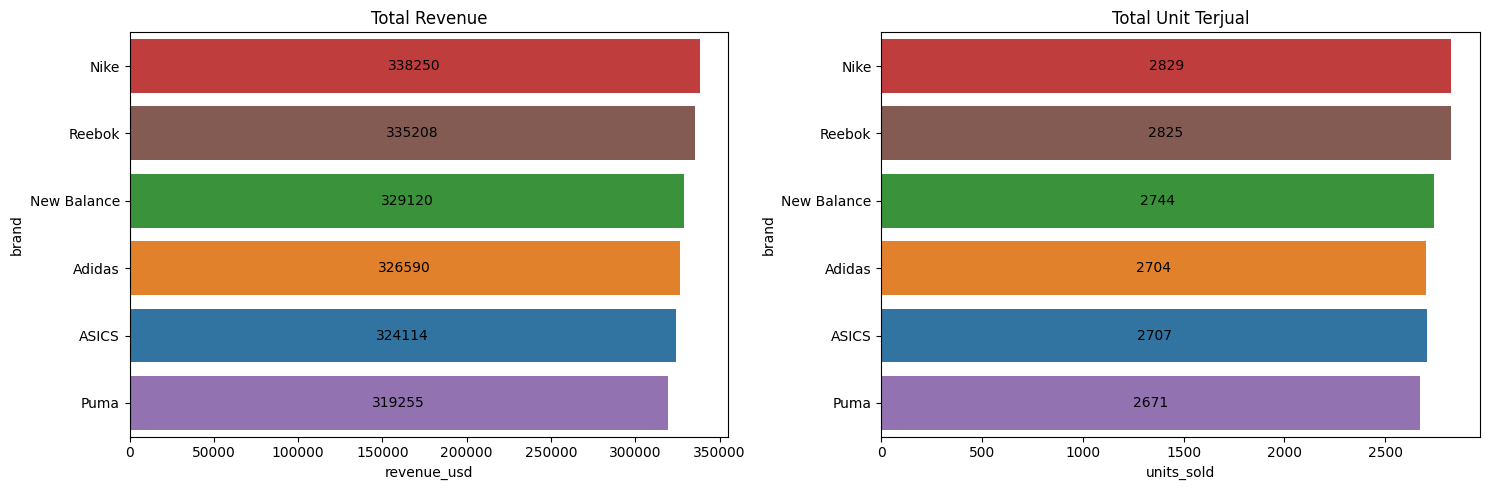

In [12]:
fig, axes = plt.subplots(1,2, figsize=(15,5))

v1 = sns.barplot(product, x='revenue_usd', y='brand', hue='brand', ax=axes[0], order=product.sort_values('revenue_usd', ascending=False).brand)
axes[0].set_title('Total Revenue')
v2 = sns.barplot(product, x='units_sold', y='brand', hue='brand', ax=axes[1], order=product.sort_values('revenue_usd', ascending=False).brand)
axes[1].set_title('Total Unit Terjual')
for ax in axes:
    for container in ax.containers:
        ax.bar_label(container,label_type='center', fmt='%.0f')

plt.tight_layout()
plt.show()


Dapat dilihat pada barchart di atas, produk yang memiliki total penjualan dan unit terjual terbesar adalah `Nike` dan yang paling sedikit adalah `Adidas`

#### 2. Channel manakah yang menghasilkan revenue tertinggi?

In [13]:
channel = df.groupby('sales_channel').agg({
    'revenue_usd' : 'sum'
}).reset_index()
channel

,sales_channel,revenue_usd
0,Online,1004511.45
1,Retail Store,968026.00


Kita akan melakukan groupin berdasarkan `sales_channel` untuk mencari total `revenue_usd` 

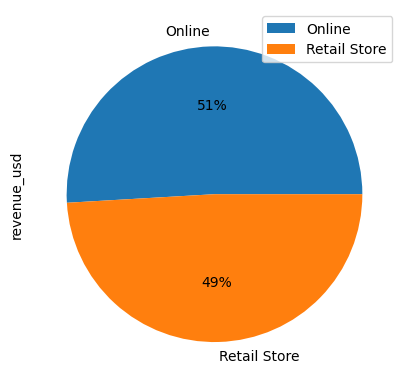

In [14]:
channel = df.groupby('sales_channel').agg({
    'revenue_usd' : 'sum'
}).plot(kind='pie', y = 'revenue_usd', autopct='%1.0f%%',)

Berdasarkan pie chart di atas, channel online menyumbang 51% dan retail stroe 49%. Hal ini menunjukkan kedua channel kontribusi kedua channel cukup seimbang. Yang berarti jenis channel tidak terlalu mempengaruhi revenue penjualan.

#### 3. Bagaimana Rata-rata Nilai Transaksi Antar Income Level?

In [15]:
income_avg = df.groupby('customer_income_level').agg({
    'revenue_usd': 'mean'
}).reset_index()


Kita akan melakukan grouping berdasarkan `customer_income_level` untuk mendapatkan rata-rata dari masing-masing `customer_income_level`

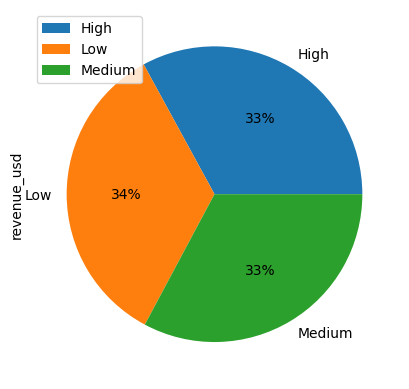

In [16]:
income_avg = df.groupby('customer_income_level').agg({
    'revenue_usd': 'mean'
}).plot(kind='pie', y = 'revenue_usd', autopct='%1.0f%%',)


Berdasarkan pie chart di atas, kategori Low menyumbang 34%, sedangkan Medium dan High masing-masing menyumbang 33% terhadap total revenue.
Hal ini menunjukkan bahwa kontribusi pendapatan dari ketiga kelompok income level relatif seimbang, meskipun kategori Low sedikit lebih dominan. Hal ini berarti daya beli pelanggan tersebar cukup merata di semua segmen income, sehingga strategi penjualan tidak hanya berfokus pada satu kelompok pelanggan saja.

#### 4. Bagaimana tren penjualan dalam 2 tahun terakhir? 

In [17]:
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month
monthly_revenue = df.groupby(['year','month'])['revenue_usd'].sum().reset_index()

Untuk mengetahui tren penjualan dalam 2 tahun terakhir, kita perlu mengekstrak bulan dan tahun dari `order_date`. Setelah itu kita akan melakukan grouping berdasarkan tahun kemudian bulan untuk mengetahui total revenuenya.

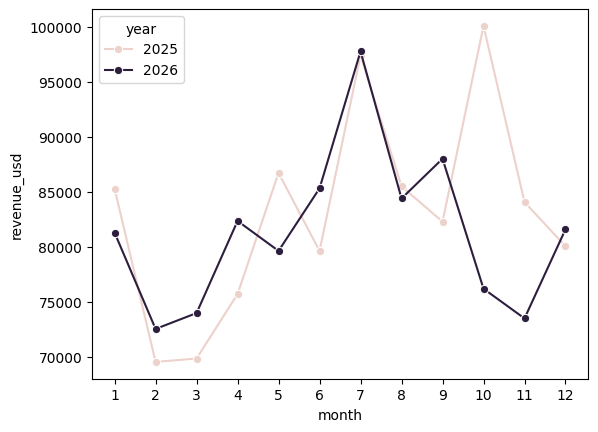

In [18]:
sns.lineplot(monthly_revenue, x='month', y='revenue_usd', hue='year', marker='o')
plt.xticks(range(1,13))

plt.show()

Berdasarkan line chart di atas dapat dilihat terdapat pola revenue yang meningkat pada periode Q2-Q3. Sedangkan pada Q1 dan Q4 cenderung terjadinya penurunan pendapatan revenue.  

#### 5. Bagaimana distribusi harga produk yang dijual?

In [19]:
mean_price = df['final_price_usd'].mean()
median_price = df['final_price_usd'].median()
mode_price = df['final_price_usd'].mode()[0]
std_price = df['final_price_usd'].std()

print("mean_final_price: ",mean_price)
print("median_final_price: ",median_price)
print("mode_final_price: ",mode_price)
print("std_final_price: ",std_price)

mean_final_price:  120.13759278897138
median_final_price:  118.75
mode_final_price:  107.1
std_final_price:  41.88492964830968


Berdasarkan analisis distribusi harga produk menggunakan central tendency, diperoleh rata-rata = 120.90 median = 119.20, dan modus = 107.1. Perbedaan antara nilai mean dan median yang cukup kecil menunjukkan bahwa distribusi harga produk cenderung hampir simetris dan menunjukkan skew yang tidak begitu besar. 
Nilai standar deviasi = 42.46 menunjukkan bahwa variasi harga produk cukup beragam. Hal ini menunjukkan bahwa perusahaan menawarkan produk dengan rentang harga yang cukup luas untuk menjangkau berbagai segmen pelanggan.

#### 6. Apakah terdapat perbedaan rata-rata revenue antar tingkat diskon?

In [20]:
low = df[(df['discount_percent'] >= 0) & 
         (df['discount_percent'] <= 10)]['revenue_usd']

medium = df[(df['discount_percent'] > 10) & 
            (df['discount_percent'] <= 20)]['revenue_usd']

high = df[(df['discount_percent'] > 20) & 
          (df['discount_percent'] <= 30)]['revenue_usd']


Untuk menjawab pertanyaan di atas, kita perlu membagi dulu besar diskon menjadi 3 tingkatan yaitu low, medium, dan high. Lalu kita ambil nilai dari `revenue_usd` pada masing-masing tingkatan. Karena kita menjadi tiga tingkatan, kita akan melakukan uji hipotesis menggunakan ANOVA.  
Dimana,  
H0: Tidak ada perbedaan rata-rata revenue antara diskon low, medium, dan high
mean_low = mean_medium = mean_high  
H1: Setidaknya ada 1 yang berbeda dari yang lain.


In [21]:
f_stat, p_value = f_oneway(low, medium, high)
f_stat, p_value

(91.17227183759591, 8.742750962983402e-40)

Karena p_value < 0.05 H0 ditolak, yang berarti terdapat perbedaan rata-rata revenue yang sangat signifikan antar kelompok diskon Low, Medium, dan High. Hal ini mengindikasikan bahwa tingkat diskon mempengaruhi besarnya revenue.  
Kita akan mencari tahu tingkatan mana yang memiliki rata-rata revenu tertinggi.

In [22]:
low = low.mean()
print(low)
medium = medium.mean()
print(medium)
high = high.mean()
print(high)

323.8159762412428
287.5664732142857
246.10454545454542


Berdasarkan rata-rata revenue per tingkatan, dapat dilihat diskon dengan tingkatan low menghasilkan rata-rata revenue tertinggi daripada yang lain.

# v. Conclusion

Berdasarkan hasil analisis, channel penjualan dan segmentasi pelanggan berdasarkan level income tidak terlalu berpengaruh terhadap revenue penjualan. Sedangkan pemilihan produk, penerapan strategi diskon, dan waktu penjualan memiliki pengaruh yang lebih besar terhadap revenue penjualan. 
 
**Rekomendasi:**  
- Mengoptimalkan penjualan produk Nike.  
- Menerapkan strategi diskon yang kecil.  
- Memaksimalkan strategi promosi dan pemasaran pada periode pertengahan tahun. 